In [1]:
# imports
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load Apple Health export XML into a single DataFrame.
# Required so we can filter by record type and compute over startDate/endDate.
def load_data(filepath):
    tree = ET.parse(filepath)
    root = tree.getroot()
    records = []
    for record in root.findall('Record'):
        records.append({
            'type': record.get('type'),
            'startDate': record.get('startDate'),
            'endDate': record.get('endDate'),
            'value': record.get('value')
        })
    df = pd.DataFrame(records)
    df['startDate'] = pd.to_datetime(df['startDate'])
    df['endDate'] = pd.to_datetime(df['endDate'])
    return df

In [3]:
# Keep only the most recent continuous segment; drop data before any gap larger than max_gap_months.
# Avoids mixing old and new behavior when the user had long periods without data (e.g. no wear).
def filter_recent_data(df, max_gap_months=1):
    df = df.sort_values('startDate').copy()
    df['startDate'] = pd.to_datetime(df['startDate'])
    gap_days = int(max_gap_months * 30)
    gaps = df['startDate'].diff().dt.days
    last_gap_idx = gaps[gaps > gap_days].last_valid_index()
    if last_gap_idx is None:
        return df
    pos = df.index.get_loc(last_gap_idx)
    return df.iloc[pos + 1:]

In [4]:
# Restrict to resting heart rate records, keep only recent segment, and aggregate to one value per day.
# Daily aggregation gives a stable signal for baseline and deviation analysis.
def extract_rhr(df):
    rhr = df[df['type'] == 'HKQuantityTypeIdentifierRestingHeartRate'].copy()
    rhr['startDate'] = pd.to_datetime(rhr['startDate'])
    rhr['value'] = pd.to_numeric(rhr['value'], errors='coerce')
    rhr = rhr.sort_values('startDate')
    rhr['date'] = rhr['startDate'].dt.normalize().dt.date
    daily = rhr.groupby('date')['value'].mean().reset_index()
    daily.columns = ['date', 'resting_hr']
    daily['date'] = pd.to_datetime(daily['date'])
    return daily

In [5]:
# Restrict to HRV (SDNN) records, keep only recent segment, and aggregate to one value per day.
# HRV is used alongside RHR for drift scoring.
def extract_hrv(df):
    hrv = df[df['type'] == 'HKQuantityTypeIdentifierHeartRateVariabilitySDNN'].copy()
    hrv['startDate'] = pd.to_datetime(hrv['startDate'])
    hrv['value'] = pd.to_numeric(hrv['value'], errors='coerce')
    hrv = hrv.sort_values('startDate')
    hrv['date'] = hrv['startDate'].dt.normalize().dt.date
    daily = hrv.groupby('date')['value'].mean().reset_index()
    daily.columns = ['date', 'hrv']
    daily['date'] = pd.to_datetime(daily['date'])
    return daily

In [6]:
# Inner join RHR and HRV on date so we only analyze days with both signals.
# Required before computing combined baselines and drift score.
def merge_rhr_hrv(daily_rhr, daily_hrv):
    return daily_rhr.merge(daily_hrv, on='date', how='inner')

In [7]:
# Add rolling baselines and deviations for RHR and HRV so we can detect sustained shifts.
# Baseline is a trailing mean; deviation is current value minus baseline.
def compute_baselines_and_deviations(combined, baseline_window=30):
    combined = combined.copy()
    combined['rhr_baseline'] = combined['resting_hr'].rolling(window=baseline_window, min_periods=7).mean()
    combined['hrv_baseline'] = combined['hrv'].rolling(window=baseline_window, min_periods=7).mean()
    combined['rhr_dev'] = combined['resting_hr'] - combined['rhr_baseline']
    combined['hrv_dev'] = combined['hrv'] - combined['hrv_baseline']
    return combined

In [8]:
# Flag days where RHR is elevated or HRV is low vs baseline, then sum into a drift score (0–2).
# Higher score indicates more deviation from baseline and possible stress/load.
def drift_score(combined, rhr_threshold=5, hrv_threshold=-10):
    combined = combined.copy()
    combined['rhr_flag'] = combined['rhr_dev'] > rhr_threshold
    combined['hrv_flag'] = combined['hrv_dev'] < hrv_threshold
    combined['drift_score'] = combined[['rhr_flag', 'hrv_flag']].astype(int).sum(axis=1)
    return combined

In [9]:
# Plot RHR and its baseline (and optionally HRV) for visual inspection of trends and drift.
# Run after the pipeline so combined has rhr_baseline and optionally hrv_baseline.
def plot_pipeline(combined, show_hrv=True):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(combined['date'], combined['resting_hr'], label='Resting HR')
    ax.plot(combined['date'], combined['rhr_baseline'], label='RHR baseline')
    if show_hrv and 'hrv' in combined.columns:
        ax2 = ax.twinx()
        ax2.plot(combined['date'], combined['hrv'], color='green', alpha=0.7, label='HRV')
        ax2.plot(combined['date'], combined['hrv_baseline'], color='green', linestyle='--', alpha=0.7, label='HRV baseline')
        ax2.set_ylabel('HRV')
        ax2.legend(loc='upper right')
    ax.set_ylabel('Resting HR')
    ax.legend(loc='upper left')
    ax.set_xlabel('Date')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

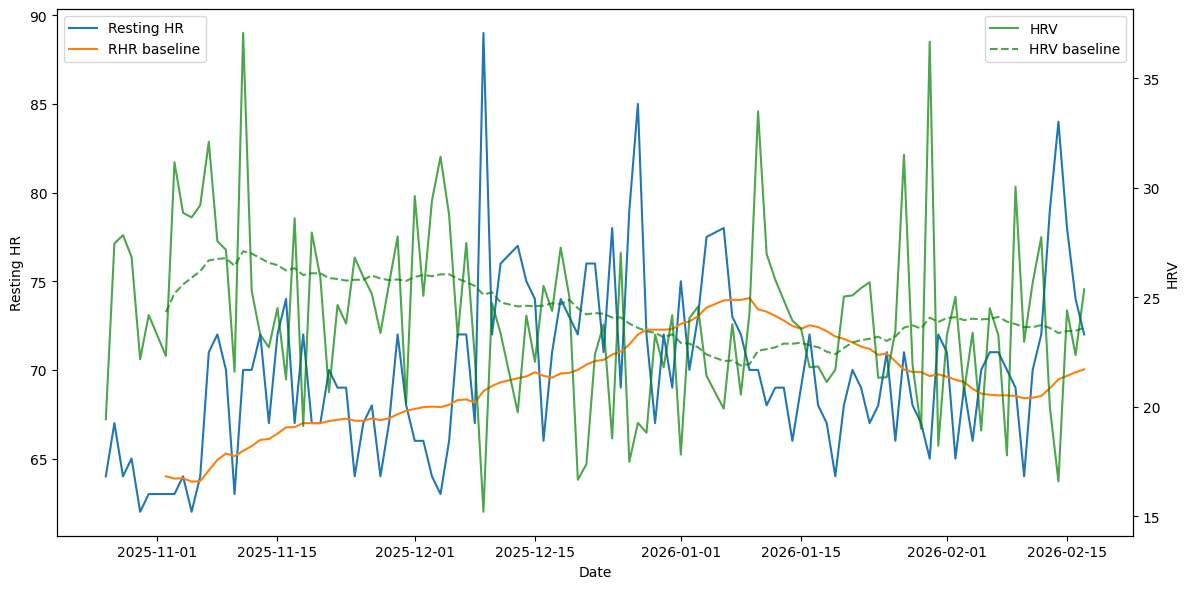

,date,rhr_dev,hrv_dev,drift_score
98,2026-02-04,-2.933333,-0.638220,0
99,2026-02-05,1.333333,-5.073152,0
100,2026-02-06,2.400000,0.487962,0
101,2026-02-07,2.433333,-0.837376,0
102,2026-02-08,1.433333,-6.106455,0
103,2026-02-09,0.466667,6.279963,0
104,2026-02-10,-4.400000,-0.675741,0
105,2026-02-11,1.566667,2.029146,0
106,2026-02-12,3.466667,4.013377,0
107,2026-02-13,10.033333,-3.608576,1


In [10]:
# Run full pipeline: load → filter recent → extract RHR/HRV → merge → baselines + deviations → drift → plot
filepath = '../data/export.xml'
max_gap_months = 1

raw = load_data(filepath)
raw = filter_recent_data(raw)
daily_rhr = extract_rhr(raw)
daily_hrv = extract_hrv(raw)
combined = merge_rhr_hrv(daily_rhr, daily_hrv)
combined = compute_baselines_and_deviations(combined)
combined = drift_score(combined)

plot_pipeline(combined)
combined.tail(14)[['date', 'rhr_dev', 'hrv_dev', 'drift_score']]